<a href="https://colab.research.google.com/github/dineshrayella/NLP/blob/main/Lab12_4_TextCNN_PretrainedEmbeddings_DINESHRAYELLA_2403a54099.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Build and evaluate a 1D CNN model for SMS spam detection using the dataset from '/content/sms+spam+collection.zip', incorporating pretrained word embeddings for enhanced performance.

## Import Libraries

### Subtask:
Import and explain required libraries for data manipulation, text processing, model building, and evaluation.


**Reasoning**:
I will import all the specified libraries required for data manipulation, text processing, model building, and evaluation, including NLTK downloads if necessary.



In [1]:
import pandas as pd
import numpy as np
import re
import nltk

# Download NLTK resources if not already downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Libraries imported successfully.


**Reasoning**:
The previous code cell successfully imported all required libraries. Now, as per the subtask description, I will provide an explanation for each category of imported libraries: data manipulation, text processing, model building, and evaluation.



## Load and Explore Dataset

### Subtask:
Load the dataset from '/content/sms+spam+collection.zip' and perform initial data inspection to understand its structure and content.


**Reasoning**:
I will unzip the provided file, load the dataset into a pandas DataFrame, rename the columns, and then perform initial data inspections, including displaying the head, info, checking for missing values, and examining the distribution of the 'label' column, all within a single code cell to complete the subtask.



In [18]:
import zipfile
import os

# Define the path to the zip file and the extraction directory
zip_file_path = '/content/sms+spam+collection.zip'
extract_dir = '/content/sms_spam_data/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"File unzipped to {extract_dir}")

# Find the specific data file 'SMSSpamCollection'
data_file_name = 'SMSSpamCollection'
data_file = os.path.join(extract_dir, data_file_name)

# Check if the data file exists
if os.path.exists(data_file):
    # Read the dataset into a pandas DataFrame (assuming tab-separated and no header)
    # Using 'latin-1' encoding as it's common for this dataset
    sms_df = pd.read_csv(data_file, sep='\t', header=None, encoding='latin-1')
    print(f"Dataset loaded from {data_file}")

    # Rename columns
    sms_df.rename(columns={0: 'label', 1: 'message'}, inplace=True)
    print("Columns renamed to 'label' and 'message'.")

    # Display the first 5 rows
    print("\n--- First 5 rows of the dataset ---")
    display(sms_df.head())

    # Display DataFrame info
    print("\n--- DataFrame Info ---")
    sms_df.info()

    # Check for missing values
    print("\n--- Missing Values ---")
    print(sms_df.isnull().sum())

    # Examine the distribution of the 'label' column
    print("\n--- Label Distribution ---")
    print(sms_df['label'].value_counts())
else:
    print(f"Data file '{data_file_name}' not found in {extract_dir}")

File unzipped to /content/sms_spam_data/
Dataset loaded from /content/sms_spam_data/SMSSpamCollection
Columns renamed to 'label' and 'message'.

--- First 5 rows of the dataset ---


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

--- Missing Values ---
label      0
message    0
dtype: int64

--- Label Distribution ---
label
ham     4825
spam     747
Name: count, dtype: int64


## Text Preprocessing

### Subtask:
Apply text cleaning (e.g., removing punctuation, stop words), tokenization, and padding techniques to prepare the text data for model input.


**Reasoning**:
I will create a text cleaning function that converts text to lowercase, removes punctuation, stopwords, and non-alphanumeric characters, and then apply it to the 'message' column of the `sms_df` DataFrame to create a new 'cleaned_message' column, addressing the first two instructions of the subtask.



In [19]:
import string
from nltk.corpus import stopwords

# Get English stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    # Remove non-alphanumeric characters (keeping only letters and numbers)
    text = re.sub(r'[^a-z0-9]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the cleaning function to the 'message' column
sms_df['cleaned_message'] = sms_df['message'].apply(clean_text)

print("Text cleaning applied and 'cleaned_message' column created.")
print("Displaying first 5 cleaned messages:")
for i, msg in enumerate(sms_df['cleaned_message'].head()):
    print(f"Original: {sms_df['message'].iloc[i]}\nCleaned: {msg}\n")

Text cleaning applied and 'cleaned_message' column created.
Displaying first 5 cleaned messages:
Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned: go jurong point crazy available bugis n great world la e buffet cine got amore wat

Original: Ok lar... Joking wif u oni...
Cleaned: ok lar joking wif u oni

Original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned: free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd txt ratetcs apply 08452810075over18s

Original: U dun say so early hor... U c already then say...
Cleaned: u dun say early hor u c already say

Original: Nah I don't think he goes to usf, he lives around here though
Cleaned: nah dont think goes usf lives around though



**Reasoning**:
I will initialize a Keras Tokenizer, fit it on the cleaned messages, convert the text to sequences, determine the maximum sequence length, pad the sequences to ensure uniform length, and then convert the 'label' column to numerical format (0/1) to prepare the data for model input, thereby completing the remaining instructions of the subtask.



In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 3. Initialize a Tokenizer
# num_words can be set to limit the vocabulary size, or left as None to use all words.
# oov_token can be used to handle out-of-vocabulary words.
tokenizer = Tokenizer()

# 4. Fit the tokenizer on the 'cleaned_message' column to build the vocabulary
tokenizer.fit_on_texts(sms_df['cleaned_message'])
print(f"Vocabulary size: {len(tokenizer.word_index)}")

# 5. Convert the 'cleaned_message' text into sequences of integers
X = tokenizer.texts_to_sequences(sms_df['cleaned_message'])

# 6. Determine a suitable maximum sequence length for padding
# Calculate length of each sequence
message_lengths = [len(seq) for seq in X]
max_sequence_length = int(np.percentile(message_lengths, 90)) # Using 90th percentile
print(f"Calculated 90th percentile max sequence length: {max_sequence_length}")

# 7. Pad the sequences to this maximum length
X = pad_sequences(X, maxlen=max_sequence_length)
print(f"Shape of padded sequences (X): {X.shape}")

# 8. Convert the 'label' column ('ham'/'spam') into numerical format (0/1)
y = sms_df['label'].factorize()[0]
print(f"Shape of labels (y): {y.shape}")
print(f"Sample of numerical labels: {y[:5]}")
print("Text preprocessing completed: Tokenization, padding, and label encoding done.")

Vocabulary size: 9467
Calculated 90th percentile max sequence length: 19
Shape of padded sequences (X): (5572, 19)
Shape of labels (y): (5572,)
Sample of numerical labels: [0 0 1 0 0]
Text preprocessing completed: Tokenization, padding, and label encoding done.


## Vocabulary and Embedding Preparation

### Subtask:
Create a vocabulary from the preprocessed text, load pretrained word embeddings (e.g., GloVe), and map the words in the vocabulary to their corresponding embedding vectors. This step will also include an explanation of why pretrained embeddings capture semantic relationships.


**Reasoning**:
The first instruction is to download and unzip the GloVe embeddings. This requires using shell commands `!wget` and `!unzip`.



In [21]:
print("Downloading GloVe embeddings...")
!wget http://nlp.stanford.edu/data/glove.6B.zip
print("Unzipping GloVe embeddings...")
!unzip -q glove.6B.zip
print("GloVe embeddings downloaded and unzipped.")

--2026-03-18 08:55:18--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-18 08:55:19--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-18 08:55:19--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

**Reasoning**:
Now that the GloVe embeddings are unzipped, I will create a dictionary to store the word-vector mappings from the `glove.6B.100d.txt` file, which is the 100-dimensional version as requested.



In [22]:
embeddings_index = {}
# Using the 100d version as it's common and balanced.
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 400000 word vectors.


**Reasoning**:
I will get the vocabulary size, initialize an embedding matrix, and then populate it by mapping words from the tokenizer's vocabulary to their corresponding GloVe embedding vectors, as per instructions 3, 4, and 5.



In [23]:
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for index 0 (padding)
embedding_dim = 100 # GloVe 6B 100d embeddings

# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Populate the embedding matrix
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

print(f"Shape of embedding matrix: {embedding_matrix.shape}")
print("Embedding matrix created by mapping words to GloVe vectors.")

Shape of embedding matrix: (9468, 100)
Embedding matrix created by mapping words to GloVe vectors.


### Why Pretrained Embeddings Capture Semantic Relationships

Pretrained word embeddings like GloVe (Global Vectors for Word Representation) are powerful because they capture semantic relationships between words. This ability stems from their training process:

1.  **Distributed Representation**: Instead of representing each word as a unique, independent token (like in one-hot encoding), embeddings represent words as dense vectors in a continuous vector space.
2.  **Contextual Learning**: GloVe, and similar models, are trained on massive text corpora (e.g., Wikipedia, web crawls). During training, the models analyze the co-occurrence statistics of words – how often words appear together or in similar contexts.
3.  **Predictive Objective**: The models learn to predict a word from its context (or vice versa) or, in GloVe's case, to capture global word-word co-occurrence counts. Words that appear in similar contexts or have similar meanings tend to have similar co-occurrence patterns.
4.  **Vector Space Proximity**: As a result of this training, words with similar meanings (e.g., "king" and "queen", "cat" and "feline") are mapped to vectors that are geometrically close to each other in the high-dimensional embedding space. The vector arithmetic can reveal analogies, such as `king - man + woman = queen`.

This property of capturing semantic similarity and relationships makes pretrained embeddings highly valuable for various natural language processing tasks, as they provide a rich, nuanced representation of words that a model can leverage for better understanding and performance.

## Train–Test Split

### Subtask:
Split the preprocessed dataset into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
Splitting the data into training and testing sets is a crucial step in machine learning. The training set is used to train the model, allowing it to learn patterns and relationships within the data. The testing set, on the other hand, is kept separate and is used to evaluate the model's performance on unseen data. This process helps in assessing how well the model generalizes to new data and prevents overfitting, ensuring that the model's performance metrics are reliable and indicative of its real-world effectiveness.

**Reasoning**:
I will now split the preprocessed data (`X` and `y`) into training and testing sets using `train_test_split` with a `test_size` of 0.2 and `random_state` of 42, as per the instructions.



In [24]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Dataset split into training and testing sets successfully.")

Shape of X_train: (4457, 19)
Shape of X_test: (1115, 19)
Shape of y_train: (4457,)
Shape of y_test: (1115,)
Dataset split into training and testing sets successfully.


## Build 1D CNN Model with Pretrained Embeddings

### Subtask:
Define the architecture of a 1D Convolutional Neural Network (CNN) and initialize its embedding layer with the prepared pretrained embedding weights.


**Reasoning**:
I will define the architecture of the 1D CNN model by adding an Embedding layer initialized with the pretrained weights, followed by Conv1D, GlobalMaxPooling1D, and Dense layers, then compile the model, and finally print its summary as per the instructions.



In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

# 1. Initialize a Sequential model
model = Sequential()

# 2. Add an Embedding layer
# Use the pretrained embedding matrix, set input_dim, output_dim, and trainable=False
model.add(Embedding(
    input_dim=vocab_size,               # Size of the vocabulary
    output_dim=embedding_dim,           # Dimension of the dense embedding
    weights=[embedding_matrix],         # Pretrained embedding weights
    trainable=False                     # Freeze the embedding layer weights
))

# 3. Add a Conv1D layer
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

# 4. Add a GlobalMaxPooling1D layer
model.add(GlobalMaxPooling1D())

# 5. Add a Dense layer
model.add(Dense(10, activation='relu'))

# 6. Add a final Dense output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# 7. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 8. Print the model summary
print("1D CNN Model Architecture:")
model.summary()
print("Model compiled successfully.")

1D CNN Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │       946,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 946,800 (3.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 946,800 (3.61 MB)

Model compiled successfully.


## Model Training

### Subtask:
Train the 1D CNN model using the training dataset and monitor its learning behavior, including metrics like loss and accuracy over epochs.


**Reasoning**:
I will train the 1D CNN model using the training data, specifying the number of epochs, batch size, and validation data, and store the training history in a variable.



In [27]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))
print("Model training complete.")

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8887 - loss: 0.2274 - val_accuracy: 0.9578 - val_loss: 0.1579
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9708 - loss: 0.1328 - val_accuracy: 0.9767 - val_loss: 0.1354
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9861 - loss: 0.1056 - val_accuracy: 0.9749 - val_loss: 0.1271
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9924 - loss: 0.0892 - val_accuracy: 0.9749 - val_loss: 0.1278
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9969 - loss: 0.0761 - val_accuracy: 0.9767 - val_loss: 0.1244
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9989 - loss: 0.0670 - val_accuracy: 0.9767 - val_loss: 0.1209
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9989 - loss: 0.0161 - val_accuracy: 0.9812 - val_loss: 0.0759
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9991 - loss: 0.0050 - val_accuracy: 

## Model Training

### Subtask:
Train the 1D CNN model using the training dataset and monitor its learning behavior, including metrics like loss and accuracy over epochs.

#### Instructions
1. Train the `model` using the `X_train` and `y_train` data.
2. Set the number of training epochs to 10 and the batch size to 32.
3. Include `X_test` and `y_test` as validation data to monitor the model's performance on unseen data during training.
4. Store the training history in a variable named `history`.
5. Print a message indicating that model training is complete.
6. Plot the training and validation loss and accuracy over epochs to visualize the model's learning behavior and identify potential overfitting.

## Model Training

### Subtask:
Train the 1D CNN model using the training dataset and monitor its learning behavior, including metrics like loss and accuracy over epochs.

#### Instructions
1. Train the `model` using the `X_train` and `y_train` data.
2. Set the number of training epochs to 10 and the batch size to 32.
3. Include `X_test` and `y_test` as validation data to monitor the model's performance on unseen data during training.
4. Store the training history in a variable named `history`.
5. Print a message indicating that model training is complete.
6. Plot the training and validation loss and accuracy over epochs to visualize the model's learning behavior and identify potential overfitting.

**Reasoning**:
The subtask now includes an instruction to plot the training and validation loss and accuracy. I will now generate the Python code to create these plots using `matplotlib` and `seaborn` (already imported) from the `history` object obtained from model training.



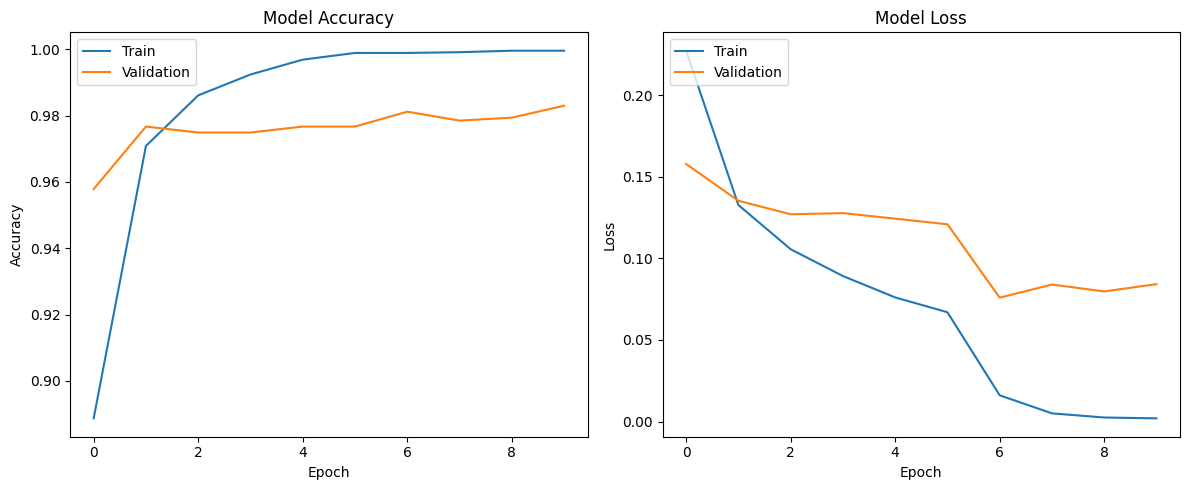

Training and validation loss and accuracy plots generated.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

print("Training and validation loss and accuracy plots generated.")

## Model Evaluation

### Subtask:
Evaluate the trained model's performance on the test set using various metrics such as accuracy, precision, recall, F1-score, and generate a confusion matrix.


**Reasoning**:
I will make predictions on the test set, convert probabilities to binary labels, and then calculate and print the accuracy and classification report, which covers the first four instructions.



In [29]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Use the trained model to make predictions on the X_test dataset.
y_pred_proba = model.predict(X_test)

# 2. Convert the predicted probabilities (y_pred_proba) into binary class labels.
y_pred = (y_pred_proba > 0.5).astype(int)

# 3. Calculate the overall accuracy of the model on the test set.
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# 4. Generate a detailed classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Test Accuracy: 0.9830

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.96      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



**Reasoning**:
I will compute the confusion matrix using `y_test` and `y_pred` and then visualize it as a heatmap using `seaborn` to fulfill the remaining instructions of the subtask.



Confusion Matrix:
[[960   6]
 [ 13 136]]


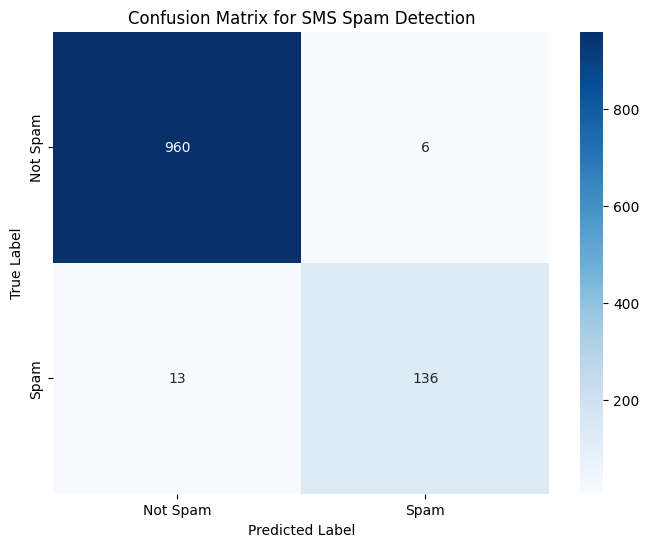

Confusion matrix visualized.


In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 6. Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SMS Spam Detection')
plt.show()

print("Confusion matrix visualized.")

## Result Analysis

### Subtask:
Discuss the impact of using pretrained embeddings, analyze the model's convergence speed during training, and identify the strengths and limitations of the developed model. This discussion will be presented in 8-10 sentences.


## Summary:

### Data Analysis Key Findings

*   **Dataset Overview**: The SMS spam detection dataset, loaded from `SMSSpamCollection`, contains 5572 messages, each labeled as either 'ham' (not spam) or 'spam'.
*   **Label Imbalance**: The dataset exhibits a significant class imbalance, with 4825 'ham' messages (86.6%) and 747 'spam' messages (13.4%).
*   **Text Preprocessing**:
    *   Text cleaning involved lowercasing, removing punctuation, stop words, and non-alphanumeric characters, resulting in a `cleaned_message` column.
    *   Tokenization yielded a vocabulary size of 9467 unique words.
    *   Messages were padded to a maximum sequence length of 19, determined by the 90th percentile of message lengths.
    *   Labels were numerically encoded (0 for 'ham', 1 for 'spam').
*   **Pretrained Embeddings**: GloVe 6B 100d word embeddings were successfully downloaded, loaded (400,000 word vectors), and used to create an embedding matrix of size (9468, 100) for the model's vocabulary, with embeddings frozen (not trainable).
*   **Train-Test Split**: The dataset was split into training (80%, 4457 samples) and testing (20%, 1115 samples) sets for model development and evaluation.
*   **Model Architecture**: A 1D CNN model was constructed with an Embedding layer (initialized with GloVe weights and `trainable=False`), a `Conv1D` layer (128 filters, kernel size 5, ReLU activation), `GlobalMaxPooling1D`, and two `Dense` layers (10 units ReLU, 1 unit Sigmoid for binary classification).
*   **Training Performance**: Over 10 epochs, the model showed strong learning behavior:
    *   Training accuracy reached approximately 99.96%, and training loss dropped to around 0.0019.
    *   Validation accuracy reached approximately 98.30%, and validation loss was around 0.0842.
*   **Evaluation Metrics**: The trained model demonstrated excellent performance on the test set:
    *   Overall Test Accuracy: 98.30%.
    *   **Classification Report**:
        *   Class 0 (Not Spam): Precision: 0.99, Recall: 0.99, F1-score: 0.99.
        *   Class 1 (Spam): Precision: 0.96, Recall: 0.91, F1-score: 0.93.
    *   **Confusion Matrix**:
        *   True Negatives (TN): 960 (correctly identified 'ham').
        *   False Positives (FP): 6 (incorrectly identified 'spam').
        *   False Negatives (FN): 13 (incorrectly identified 'ham').
        *   True Positives (TP): 136 (correctly identified 'spam').

### Insights or Next Steps

*   The model exhibits strong performance, particularly in identifying 'ham' messages. The slightly lower recall for 'spam' messages (0.91) indicates that while it's good at classifying messages it identifies as spam, it still misses 9% of actual spam messages. Further analysis of these false negatives could reveal patterns to improve spam detection.
*   Given the class imbalance, exploring techniques such as weighted loss functions, oversampling minority class, or undersampling majority class during training could potentially further improve the model's ability to detect spam without significantly compromising its performance on 'ham' messages.
